# Nepal District-Level Cereal Yield Prediction — Linear Regression (with Recursive Feature Elimination)

This notebook trains a **Linear Regression** model separately for each of the 5 crops (Barley, Buckwheat, Maize, Millet, Wheat), using **RFECV** (Recursive Feature Elimination with Cross-Validation) to select the optimal feature subset per crop, rather than using all 90 features for every crop.

**Feature selection strategy:** per-crop RFECV, since each crop has a different sample size / data sparsity, and a shared feature set would force sparse crops (Buckwheat, Millet, Barley) to use feature counts tuned for data-rich crops (Maize, Wheat). RFECV nested inside `GroupKFold` (grouped by `District`) selects the feature count automatically per crop, which naturally shrinks toward fewer features for sparser crops rather than overfitting a fixed count.

**Evaluation:** after RFE selects features, the final model is scored two ways using the selected feature subset only:
- **LOYO** (Leave-One-Year-Out, via GroupKFold on Year) — temporal generalization

**Data quality note:** one Buckwheat row (DHANKUTA, 2023) has an agronomically impossible yield of 101.25 Mt/Ha (Area=4 Ha, Production=405 Mt — a source data error, not a computation error). Any yield value above 8 Mt/Ha (well above the realistic max for every other crop in this dataset) is treated as missing before modeling. This is a fixed domain-plausibility rule applied identically regardless of downstream model performance — not model-guided data removal.


In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_selection import RFECV
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42
MODEL_LABEL = 'Linear Regression'


## 1. Load and clean data

In [2]:
DATA_PATH = r"/Users/macbook/Downloads/Alpha_earth/merged_dataset/nepal_merged_dataset_without_buckwheat.csv"

df = pd.read_csv(DATA_PATH, skipinitialspace=True)
df.columns = [c.strip() for c in df.columns]

# Strip whitespace from every string/object cell (fixed-width source formatting)
for c in df.columns:
    if df[c].dtype == object or str(df[c].dtype) == 'str':
        df[c] = df[c].astype(str).str.strip()

CAT_ID_COLS = ['District_Key', 'District', 'Year_BS', 'Province', 'Landform', 'Parent_Material', 'Dominant_Soil']

# Coerce every non-identifier/categorical column to numeric, turning 'N/A' into NaN
for c in df.columns:
    if c not in CAT_ID_COLS:
        df[c] = pd.to_numeric(df[c].replace('N/A', np.nan), errors='coerce')

print('Shape:', df.shape)
print('Districts:', df['District'].nunique(), ' Years:', sorted(df['Year_AD'].unique()))


Shape: (385, 95)
Districts: 77  Years: [2019, 2020, 2022, 2023, 2024]


## 2. Domain-plausibility filter on yield (data quality fix)

In [3]:
CROPS = ['Barley', 'Maize', 'Millet', 'Wheat']
YIELD_CEILING_MTHA = 8.0  # generous ceiling; realistic district-average yields in this dataset top out well under this

for crop in CROPS:
    col = f'{crop}_Yield_MtHa'
    bad = df[col] > YIELD_CEILING_MTHA
    if bad.sum() > 0:
        print(f'{crop}: flagging {bad.sum()} implausible yield row(s) as missing:')
        print(df.loc[bad, ['District', 'Year_AD', f'{crop}_Area_Ha', f'{crop}_Production_Mt', col]])
        df.loc[bad, col] = np.nan


## 3. Build feature matrix

Features: 64 AlphaEarth embeddings (A00–A63) + terrain (elevation, slope, area, lat/long) + soil chemistry (N, P, K, organic matter, pH) + one-hot encoded categorical terrain/soil class (Landform, Parent Material, Dominant Soil).

In [4]:
EMBED_COLS = [f'A{i:02d}' for i in range(64)]
TERRAIN_COLS = ['Elevation_Min', 'Elevation_Max', 'Slope_Median', 'area', 'longitude', 'latitude']
SOIL_COLS = ['Potassium_mean', 'Nitrogen_mean', 'OrganicMatter_mean', 'Phosphorous_mean', 'pH_mean']
CAT_FEATURE_COLS = ['Landform', 'Parent_Material', 'Dominant_Soil']

X_num = df[EMBED_COLS + TERRAIN_COLS + SOIL_COLS].copy()
X_cat = pd.get_dummies(df[CAT_FEATURE_COLS], drop_first=True)
X_full = pd.concat([X_num, X_cat], axis=1)
FEATURE_NAMES = X_full.columns.tolist()

print('Total candidate features:', X_full.shape[1])


Total candidate features: 90


## 4. Per-crop RFECV + evaluation loop

In [5]:
def get_crop_data(crop):
    target_col = f'{crop}_Yield_MtHa'
    mask = df[target_col].notna() & X_full.notna().all(axis=1)
    X = X_full[mask].reset_index(drop=True)
    y = df.loc[mask, target_col].reset_index(drop=True)
    groups_district = df.loc[mask, 'District'].reset_index(drop=True)
    groups_year = df.loc[mask, 'Year_AD'].reset_index(drop=True)
    return X, y, groups_district, groups_year

def evaluate_groupcv(model_ctor_fn, X, y, groups, n_splits):
    n_splits = min(n_splits, groups.nunique())
    gkf = GroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all = [], []
    for train_idx, test_idx in gkf.split(X, y, groups):
        m = model_ctor_fn()
        m.fit(X.iloc[train_idx], y.iloc[train_idx])
        preds = m.predict(X.iloc[test_idx])
        y_true_all.extend(y.iloc[test_idx].tolist())
        y_pred_all.extend(preds.tolist())
    r2 = r2_score(y_true_all, y_pred_all)
    rmse = mean_squared_error(y_true_all, y_pred_all) ** 0.5
    mae = mean_absolute_error(y_true_all, y_pred_all)
    return r2, rmse, mae, np.array(y_true_all), np.array(y_pred_all)


In [10]:
def model_ctor():
    return LinearRegression()

def rfe_model_ctor():
    # Cheaper estimator used only during RFECV elimination steps (final model uses model_ctor)
    return LinearRegression()

results = []
selected_features_by_crop = {}
fitted_models_by_crop = {}
loyo_oof_by_crop = {}   # (y_true, y_pred) out-of-fold predictions, for predicted-vs-actual plots

for crop in CROPS:
    print('=' * 70)
    print(crop)
    X, y, groups_district, groups_year = get_crop_data(crop)
    n_samples = len(y)
    n_districts = groups_district.nunique()
    n_years = groups_year.nunique()
    print(f'n_samples={n_samples}  n_districts={n_districts}  n_years={n_years}')

    scaler = StandardScaler()
    X_arr = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_arr, columns=X.columns)

    # --- RFECV: select features via GroupKFold on District (avoids spatial leakage) ---
    rfe_splits = min(5, n_districts)
    gkf_rfe = GroupKFold(n_splits=rfe_splits)
    selector = RFECV(
        estimator=rfe_model_ctor(),
        step=20,
        min_features_to_select=5,
        cv=list(gkf_rfe.split(X_scaled, y, groups_district)),
        scoring='r2',
        n_jobs=-1,
    )
    selector.fit(X_scaled, y)
    selected_features = X_scaled.columns[selector.support_].tolist()
    selected_features_by_crop[crop] = selected_features
    print(f'RFECV selected {selector.n_features_} / {X_scaled.shape[1]} features')

    X_sel = X_scaled[selected_features]

    # --- Evaluate the selected feature subset with LOYO outer CV ---
    r2_loyo, rmse_loyo, mae_loyo, y_true_loyo, y_pred_loyo = evaluate_groupcv(model_ctor, X_sel, y, groups_year, n_splits=n_years)
    loyo_oof_by_crop[crop] = (y_true_loyo, y_pred_loyo)

    print(f'LOYO  R2={r2_loyo:.3f}  RMSE={rmse_loyo:.3f}  MAE={mae_loyo:.3f}')

    # --- Fit final model on all available data with selected features ---
    final_model = model_ctor()
    final_model.fit(X_sel, y)
    fitted_models_by_crop[crop] = final_model

    results.append({
        'Crop': crop,
        'N_samples': n_samples,
        'N_features_selected': selector.n_features_,
        'LOYO_R2': r2_loyo, 'LOYO_RMSE': rmse_loyo, 'LOYO_MAE': mae_loyo,
    })


Barley
n_samples=364  n_districts=76  n_years=5
RFECV selected 10 / 90 features
LOYO  R2=0.091  RMSE=0.391  MAE=0.273
Maize
n_samples=384  n_districts=77  n_years=5
RFECV selected 30 / 90 features
LOYO  R2=0.433  RMSE=0.631  MAE=0.484
Millet
n_samples=352  n_districts=73  n_years=5
RFECV selected 5 / 90 features
LOYO  R2=0.121  RMSE=0.238  MAE=0.161
Wheat
n_samples=384  n_districts=77  n_years=5
RFECV selected 10 / 90 features
LOYO  R2=0.537  RMSE=0.549  MAE=0.431


## 5. Results summary

In [11]:
results_df = pd.DataFrame(results)
results_df


,Crop,N_samples,N_features_selected,LOYO_R2,LOYO_RMSE,LOYO_MAE
0,Barley,364,10,0.090942,0.390557,0.273101
1,Maize,384,30,0.432781,0.630937,0.483683
2,Millet,352,5,0.121233,0.237719,0.160523
3,Wheat,384,10,0.536916,0.548774,0.430705


## 6. Selected features per crop

In [12]:
for crop, feats in selected_features_by_crop.items():
    print(f'{crop} ({len(feats)} features):')
    print('  ', feats)
    print()


Barley (10 features):
   ['A00', 'A01', 'A06', 'A37', 'A41', 'A45', 'A61', 'A62', 'A63', 'Elevation_Min']

Maize (30 features):
   ['A01', 'A03', 'A05', 'A06', 'A11', 'A16', 'A17', 'A21', 'A23', 'A25', 'A26', 'A27', 'A29', 'A30', 'A31', 'A34', 'A35', 'A37', 'A38', 'A43', 'A46', 'A50', 'A52', 'A53', 'A56', 'A57', 'A59', 'A61', 'A62', 'Slope_Median']

Millet (5 features):
   ['A20', 'A21', 'A43', 'A53', 'A61']

Wheat (10 features):
   ['A08', 'A25', 'A27', 'A53', 'A55', 'A61', 'A62', 'Slope_Median', 'longitude', 'latitude']



## 7. Visualizations

### 7a. R² by crop and CV scheme

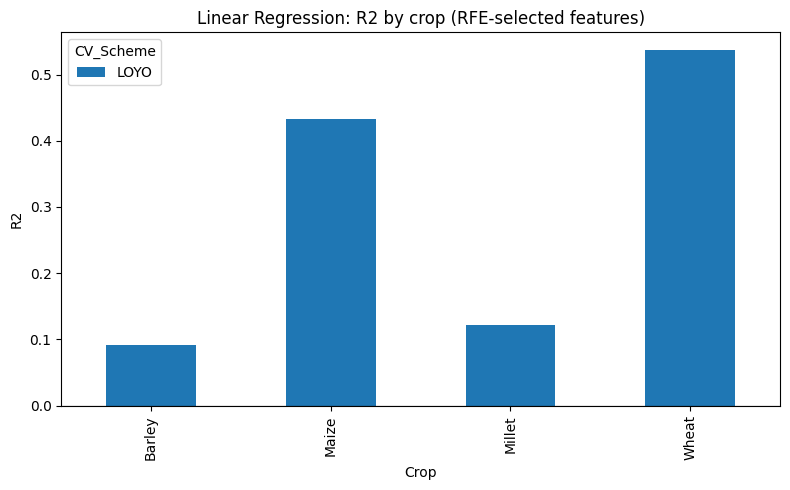

In [13]:
import matplotlib.pyplot as plt

long_df = results_df.melt(
    id_vars='Crop', value_vars=['LOYO_R2'],
    var_name='CV_Scheme', value_name='R2'
)
long_df['CV_Scheme'] = long_df['CV_Scheme'].str.replace('_R2', '')

fig, ax = plt.subplots(figsize=(8, 5))
pivot = long_df.pivot(index='Crop', columns='CV_Scheme', values='R2').loc[CROPS]
pivot.plot(kind='bar', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('R2')
ax.set_title(f'{MODEL_LABEL}: R2 by crop (RFE-selected features)')
plt.tight_layout()
plt.show()


### 7b. Number of RFE-selected features per crop

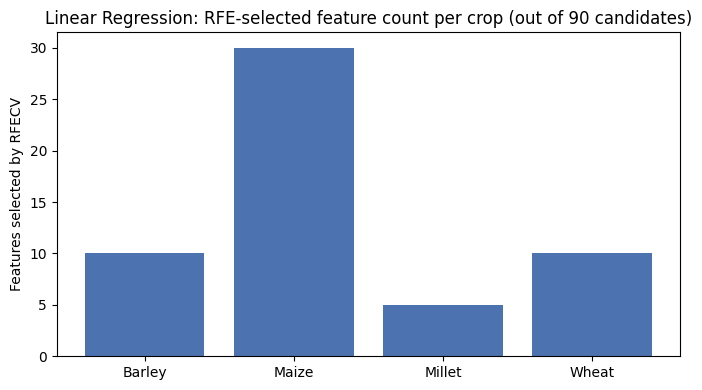

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(results_df['Crop'], results_df['N_features_selected'], color='#4C72B0')
ax.set_ylabel('Features selected by RFECV')
ax.set_title(f'{MODEL_LABEL}: RFE-selected feature count per crop (out of {X_full.shape[1]} candidates)')
plt.tight_layout()
plt.show()


### 7c. Predicted vs. actual yield (LODO out-of-fold predictions)

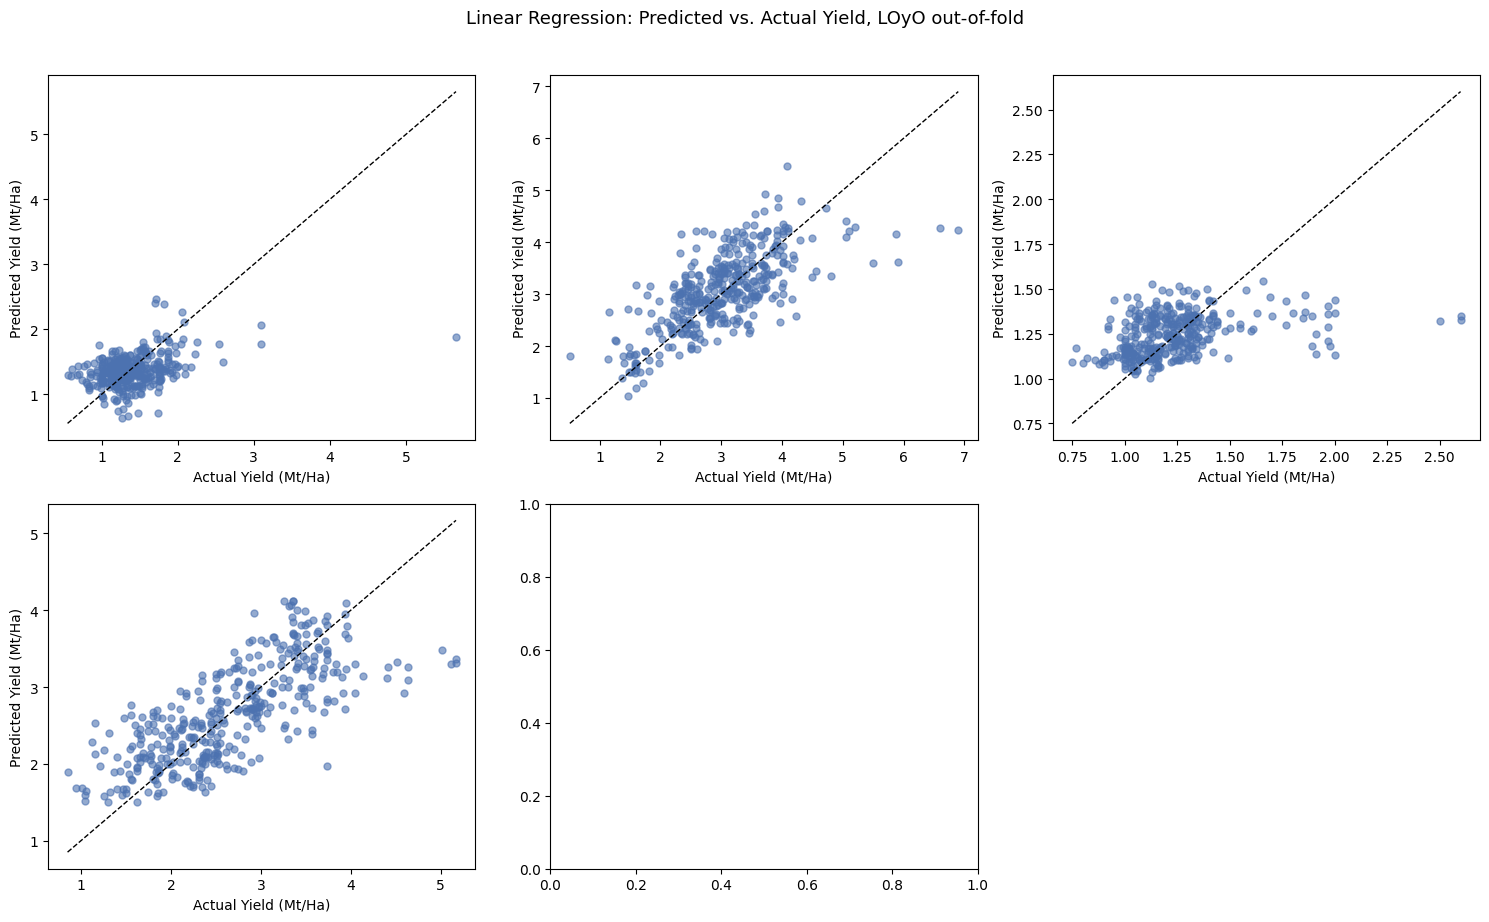

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, crop in enumerate(CROPS):
    y_true, y_pred = loyo_oof_by_crop[crop]
    ax = axes[i]
    ax.scatter(y_true, y_pred, alpha=0.6, s=25, color='#4C72B0')
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1)
    ax.set_xlabel('Actual Yield (Mt/Ha)')
    ax.set_ylabel('Predicted Yield (Mt/Ha)')
axes[-1].axis('off')
fig.suptitle(f'{MODEL_LABEL}: Predicted vs. Actual Yield, LOyO out-of-fold', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


### 7d. Model coefficients (top selected features, by crop)

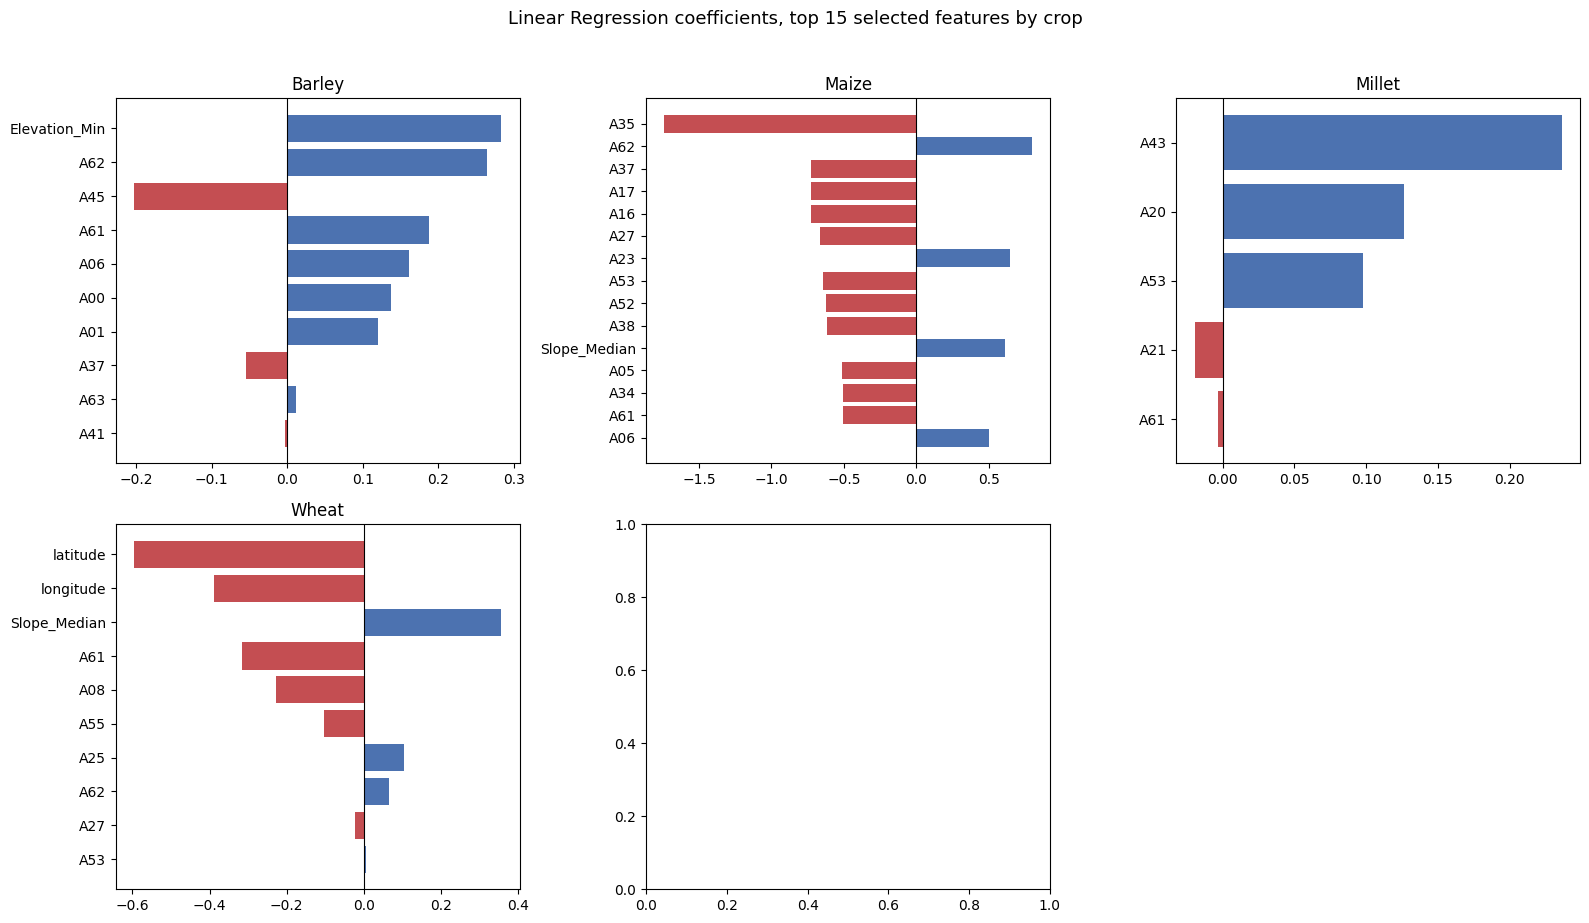

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, crop in enumerate(CROPS):
    feats = selected_features_by_crop[crop]
    coefs = fitted_models_by_crop[crop].coef_
    imp = pd.Series(coefs, index=feats).sort_values(key=abs, ascending=True).tail(15)
    ax = axes[i]
    colors = ['#C44E52' if v < 0 else '#4C72B0' for v in imp.values]
    ax.barh(imp.index, imp.values, color=colors)
    ax.set_title(f'{crop}')
    ax.axvline(0, color='black', linewidth=0.8)
axes[-1].axis('off')
fig.suptitle(f'{MODEL_LABEL} coefficients, top 15 selected features by crop', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


## 8. Save models, selected features, and metrics

In [17]:
import os
import json
import joblib

# Create a local output folder next to your notebook
output_dir = os.path.join(os.getcwd(), "outputs")
models_dir = os.path.join(output_dir, "models")

os.makedirs(models_dir, exist_ok=True)

# Save each XGBoost model
for crop, model in fitted_models_by_crop.items():
    model_path = os.path.join(
        models_dir,
        f"xgboost_{crop.lower()}_rfe.joblib"
    )
    joblib.dump(model, model_path)
    print(f"Saved model: {model_path}")

# Save results CSV
results_path = os.path.join(
    output_dir,
    "xgboost_rfe_results.csv"
)
results_df.to_csv(results_path, index=False)

# Save selected features
features_path = os.path.join(
    output_dir,
    "xgboost_rfe_selected_features.json"
)

with open(features_path, "w") as f:
    json.dump(selected_features_by_crop, f, indent=2)

print("\nAll files saved successfully!")
print(f"Output folder: {output_dir}")


Saved model: /Users/macbook/Downloads/Alpha_earth/Models/outputs/models/xgboost_barley_rfe.joblib
Saved model: /Users/macbook/Downloads/Alpha_earth/Models/outputs/models/xgboost_maize_rfe.joblib
Saved model: /Users/macbook/Downloads/Alpha_earth/Models/outputs/models/xgboost_millet_rfe.joblib
Saved model: /Users/macbook/Downloads/Alpha_earth/Models/outputs/models/xgboost_wheat_rfe.joblib

All files saved successfully!
Output folder: /Users/macbook/Downloads/Alpha_earth/Models/outputs
